# Cargar CSV en pandas

Este notebook carga el archivo CSV disponible en la carpeta del proyecto en un DataFrame de pandas.

In [5]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [6]:
# Ruta del archivo CSV
csv_path = Path("imputaciones-y-condenas-a-personas.csv")

# Cargar a DataFrame de pandas (con fallback de codificacion)
try:
    df = pd.read_csv(csv_path, sep=",", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, sep=",", encoding="latin1")

print(f"Archivo cargado: {csv_path}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Archivo cargado: imputaciones-y-condenas-a-personas.csv
Filas: 122255 | Columnas: 19


In [7]:
# Vista previa de los datos
df.head()

,id_ncci,id_nunc,id_documento,Titulo_denuncia,depto_hechos,fecha_hecho,mes_primera_audi,fecha_primera_audi,fecha_resolución,edad,edad_tramos,sexo_persona,delito_imputado,delitos_agrupados,situación_procesal,delito_1,delito_2,delito_3,delito_4
0,65259fe81b747c5bf850a4d0285f109f,5d80fd27a6f284d2f0704e26dd65494e,a473c2e40ac3f3b2803fd2d7ee276ce6,HURTO,MONTEVIDEO,2017-11-01,2019-08,2019-08-14,2019-08-14,"36,0",36-45,M,HURTO,HURTO,SUSPENSION CONDICIONAL,HURTO,NaN,NaN,NaN
1,a57b0000d41f403eae7fb5a6c208f472,cbb57405725f99f5bd24e8a0c4fd20b1,852bf4b2517ee362ecefb419b5e1e7ff,LESIONES PERSONALES,MONTEVIDEO,2017-11-01,2019-03,2019-03-19,2019-03-19,"38,0",36-45,M,HOMICIDIO,HOMICIDIO,PROCESO ABREVIADO/ SIMPLIFICADO,HOMICIDIO,NaN,NaN,NaN
2,c6055dbbc381abb7b79781b4fcb67b9a,917a60406934e5276b51f504ebe8d873,28c4a81db66f7b2e3995e5a7f5a673ae,HURTO,MONTEVIDEO,2017-10-29,2020-06,2020-06-22,2020-06-22,"18,0",18-25,M,RECEPTACIÓN,OTROS DELITOS,PROCESO ABREVIADO/ SIMPLIFICADO,RECEPTACIÓN,NaN,NaN,NaN
3,909c4f4fea09b74cf788cd7e94ee7d1d,8332a330ab57c92aaaff58a7f3dd3f24,b31313f0b13d7011c730ef1b226f6429,ATENTADO VIOLENTO AL PUDOR,RIVERA,2017-11-01,2023-05,2023-05-03,2023-05-03,"41,0",36-45,M,ATENTADO VIOLENTO AL PUDOR,Delitos sexuales,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO VIOLENTO AL PUDOR,NaN,NaN,NaN
4,2cd1030ef397b7cba4a594fb50f6eeae,4a4d10eded8945c32f403dfa594a2238,e3d6f98d8ccaf47c4b7d9f0940a25ea1,CHEQUES,MONTEVIDEO,2017-10-31,2020-09,2020-09-23,2020-09-23,"41,0",36-45,F,CHEQUES,CHEQUES,PROCESO ABREVIADO/ SIMPLIFICADO,CHEQUES,NaN,NaN,NaN


# ordenamiento de delitos por tipo

In [8]:
# Diagnostico de fechas centinela (1900-01-01 u otras fuera de rango)
sentinela = pd.Timestamp('1900-01-01')

print("Filas con fecha_hecho == 1900-01-01:", (df['fecha_hecho'] == sentinela).sum())
print("Filas con fecha_hecho < 2000-01-01:", (df['fecha_hecho'] < '2000-01-01').sum())

df.loc[df['fecha_hecho'] < '2000-01-01', 'depto_hechos'].value_counts()

Filas con fecha_hecho == 1900-01-01: 0
Filas con fecha_hecho < 2000-01-01: 7


depto_hechos
ARTIGAS       2
CANELONES     1
FLORES        1
DURAZNO       1
PAYSANDU      1
MONTEVIDEO    1
Name: count, dtype: int64

In [9]:
# Asegurar formato de fecha
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], errors='coerce')

# Filtrar filas con fecha, departamento y delito válidos
# (se descartan tambien fechas centinela como 1900-01-01, que no son hechos reales sino
# valores por defecto de carga: 7 filas en todo el dataset, ver diagnostico mas abajo)
df_delitos_departamento = df.dropna(subset=['fecha_hecho', 'depto_hechos', 'delitos_agrupados']).copy()
df_delitos_departamento = df_delitos_departamento[
    df_delitos_departamento['fecha_hecho'] >= pd.Timestamp('2000-01-01')
].copy()

# Dataset ordenado de forma descendente por numero de delitos
tipo_delitos_ordenados = (
    df_delitos_departamento.groupby('delitos_agrupados', as_index=False)
    .size()
    .rename(columns={'size': 'numero_delitos'})
    .sort_values('numero_delitos', ascending=False)
    .reset_index(drop=True)
)

# Agrupar por mes para ver evolución temporal
evolucion = (
    df_delitos_departamento
    .assign(periodo=df_delitos_departamento['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

print(f'Registros para análisis: {len(df_delitos_departamento)}')
tipo_delitos_ordenados.head(20)

Registros para análisis: 122219


,delitos_agrupados,numero_delitos
0,HURTO,40491
1,OTROS DELITOS,26426
2,ESTUPEFACIENTES,9520
3,RAPIÑA,8998
4,VIOLENCIA DOMÉSTICA,7038
5,DESACATO,6101
6,Armas de fuego y explosivos,4801
7,HOMICIDIO,3289
8,Delitos sexuales,3175
9,LESIONES PERSONALES,3117


In [10]:
## Ordenamiento de delitos por departamento


In [11]:

# Dataset ordenado de forma descendente por numero de delitos por departamento
delitos_por_departamento = (
    df_delitos_departamento.groupby('depto_hechos', as_index=False)
    .size()
    .rename(columns={'size': 'numero_delitos'})
    .sort_values('numero_delitos', ascending=False)
    .reset_index(drop=True)
)

# Agrupar por mes para ver evolución temporal
evolucion = (
    df_delitos_departamento
    .assign(periodo=df_delitos_departamento['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

print(f'Registros para análisis: {len(df_delitos_departamento)}')
delitos_por_departamento

Registros para análisis: 122219


,depto_hechos,numero_delitos
0,MONTEVIDEO,43774
1,CANELONES,18304
2,MALDONADO,7478
3,SALTO,5832
4,CERRO LARGO,4933
5,RIVERA,4924
6,PAYSANDU,4591
7,SORIANO,4159
8,SAN JOSE,4149
9,COLONIA,3454


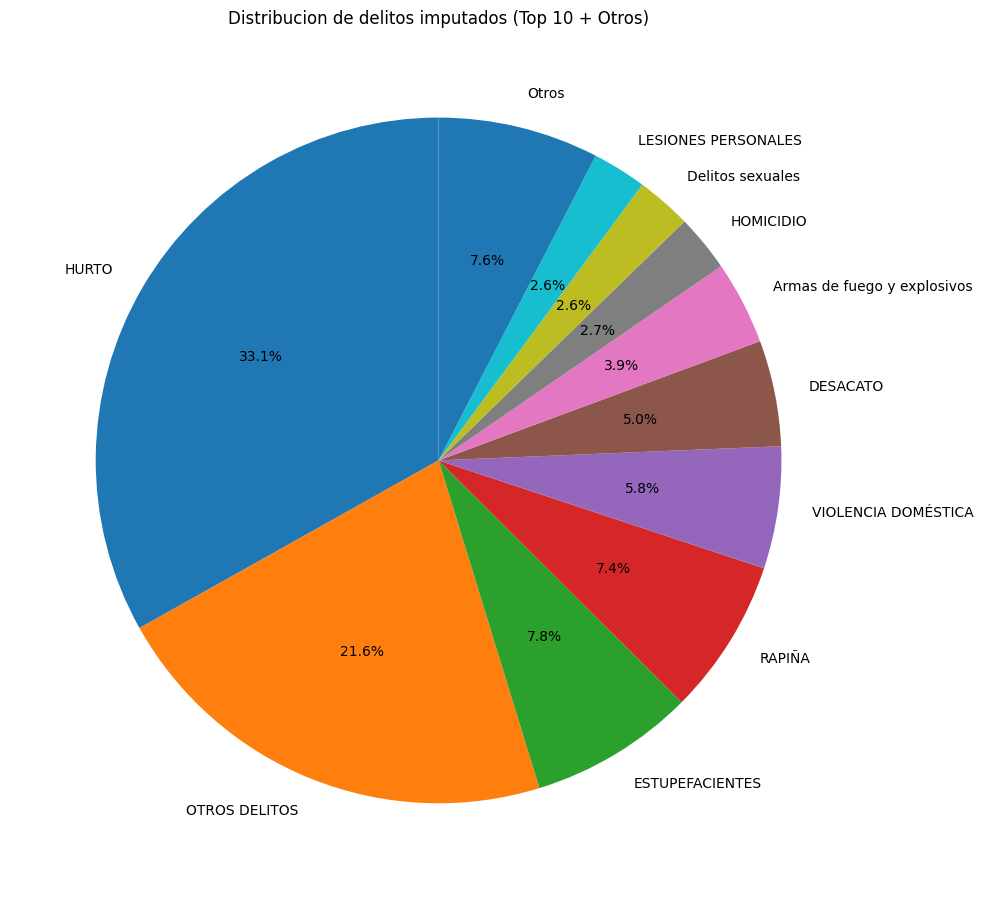

In [12]:
# Pie chart por delito imputado (Top 10 + Otros)
top10 = tipo_delitos_ordenados.head(10).copy()
otros = tipo_delitos_ordenados['numero_delitos'].iloc[10:].sum()

pie_data = top10[['delitos_agrupados', 'numero_delitos']].copy()
pie_data.loc[len(pie_data)] = ['Otros', otros]

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data['numero_delitos'],
    labels=pie_data['delitos_agrupados'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribucion de delitos imputados (Top 10 + Otros)')
plt.tight_layout()
plt.show()

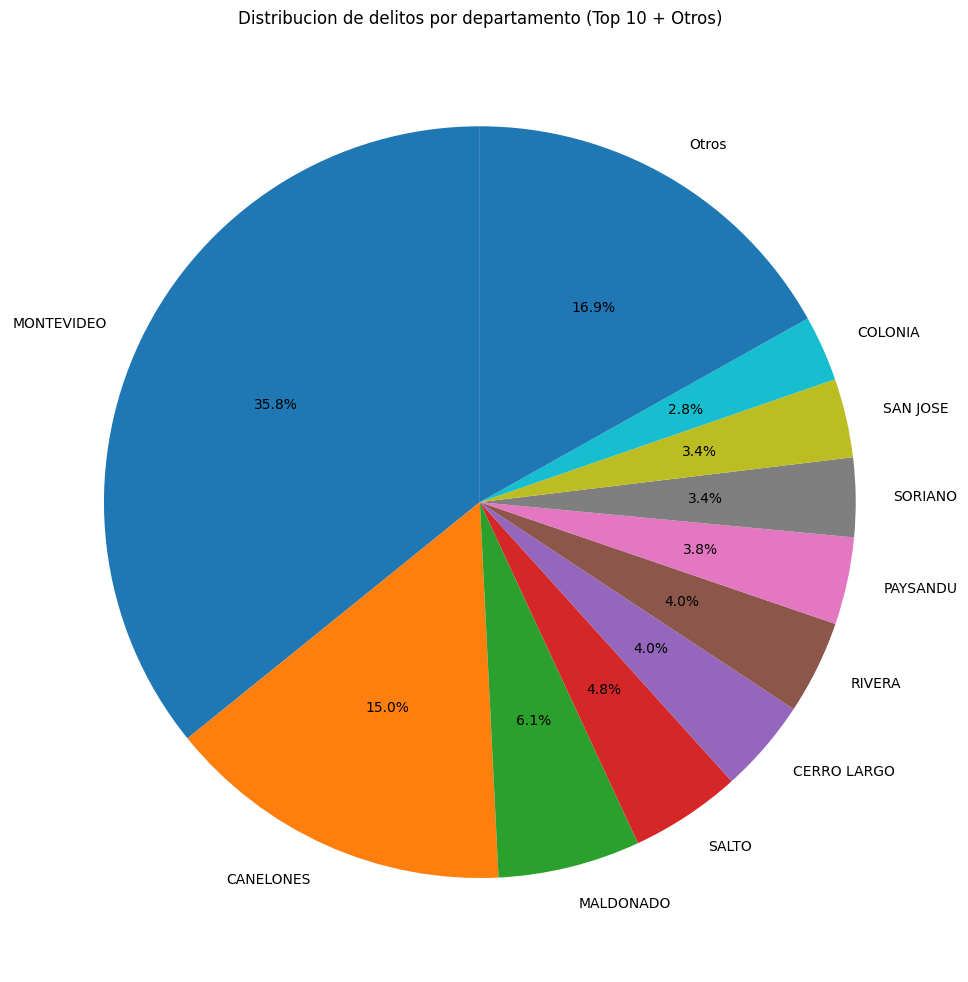

In [13]:
# Pie chart por departamento (Top 10 + Otros)
top10 = delitos_por_departamento.head(10).copy()
otros = delitos_por_departamento['numero_delitos'].iloc[10:].sum()

pie_data = top10[['depto_hechos', 'numero_delitos']].copy()
pie_data.loc[len(pie_data)] = ['Otros', otros]

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data['numero_delitos'],
    labels=pie_data['depto_hechos'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribucion de delitos por departamento (Top 10 + Otros)')
plt.tight_layout()
plt.show()

## Evolución temporal de delito_imputado por depto_hechos
Se convierte `fecha_hecho` a fecha, se agrupa por mes/departamento/delito y se grafica la cantidad de casos en el tiempo.

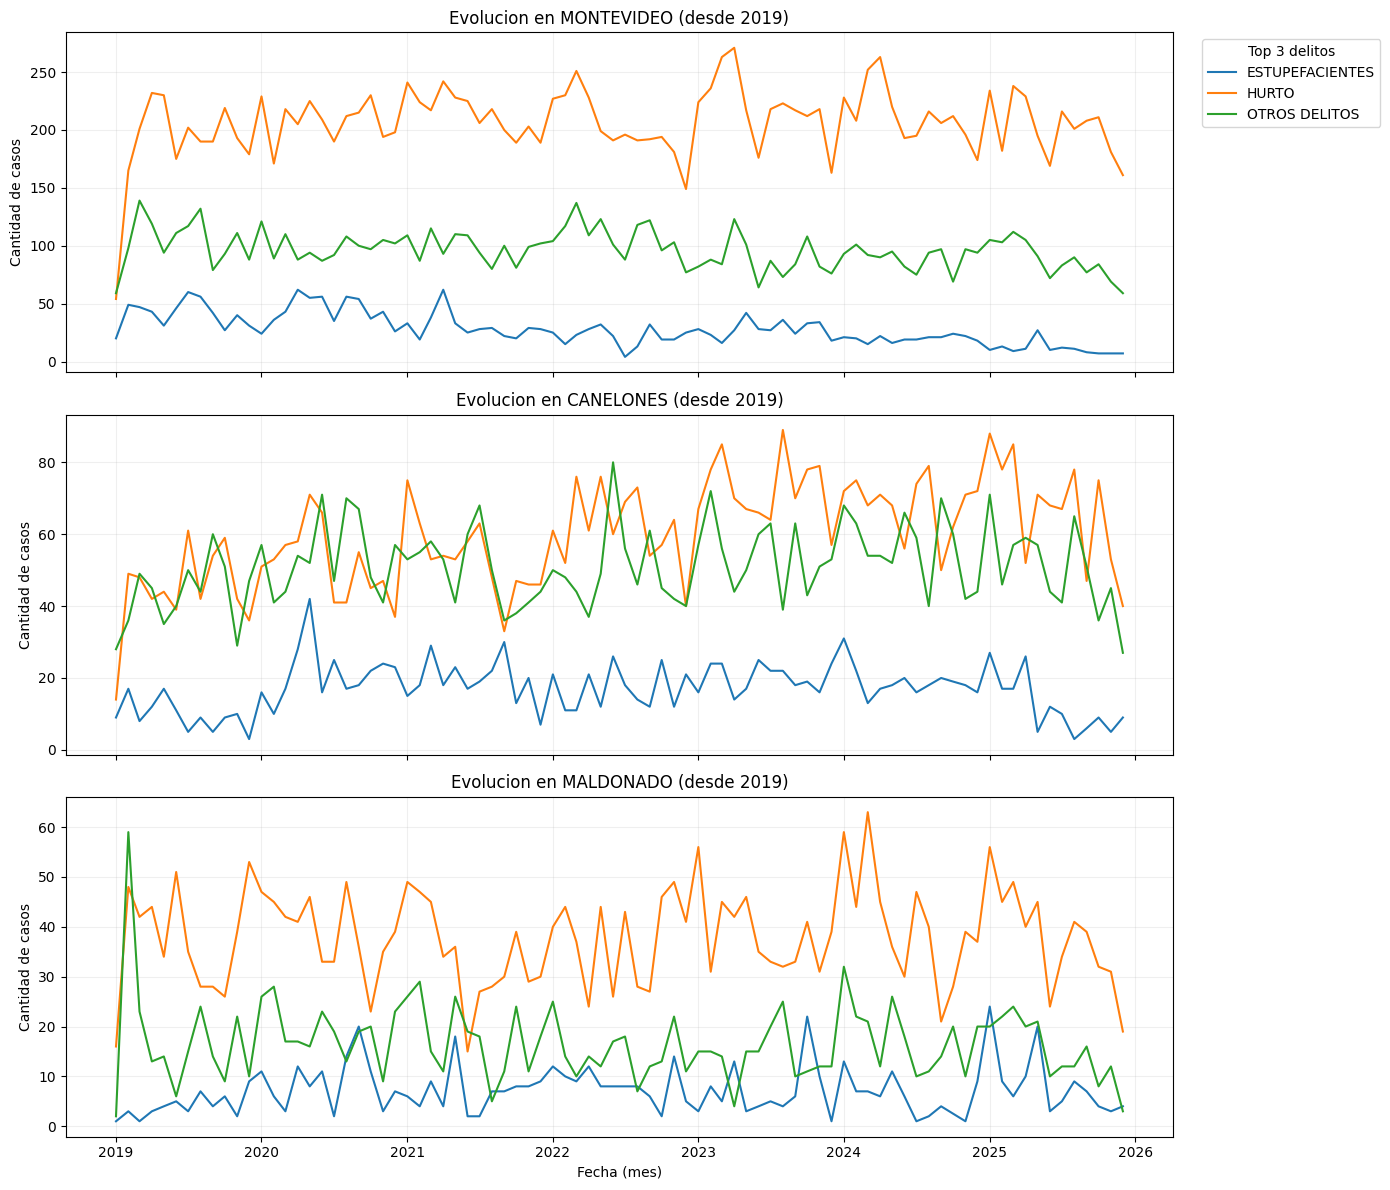

Top 3 delitos (desde 2019): ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES']
Top 3 departamentos (desde 2019): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']


In [14]:
# Top 3 delitos en Top 3 departamentos (filtrado desde 2019)
fecha_inicio = pd.Timestamp('2019-01-01')
base_2019 = df_delitos_departamento[df_delitos_departamento['fecha_hecho'] >= fecha_inicio].copy()

top3_delitos_2019 = (
    base_2019.groupby('delitos_agrupados', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['delitos_agrupados']
    .tolist()
)

top3_deptos_2019 = (
    base_2019.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

evolucion_2019 = (
    base_2019
    .assign(periodo=base_2019['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

evolucion_top_2019 = evolucion_2019[
    evolucion_2019['delitos_agrupados'].isin(top3_delitos_2019) &
    evolucion_2019['depto_hechos'].isin(top3_deptos_2019)
]

fig, axes = plt.subplots(len(top3_deptos_2019), 1, figsize=(14, 12), sharex=True)
if len(top3_deptos_2019) == 1:
    axes = [axes]

for ax, depto in zip(axes, top3_deptos_2019):
    data_depto = evolucion_top_2019[evolucion_top_2019['depto_hechos'] == depto]
    for delito, grp in data_depto.groupby('delitos_agrupados'):
        grp = grp.sort_values('periodo')
        ax.plot(grp['periodo'], grp['cantidad'], label=delito)
    ax.set_title(f'Evolucion en {depto} (desde 2019)')
    ax.set_ylabel('Cantidad de casos')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Fecha (mes)')
axes[0].legend(title='Top 3 delitos', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Top 3 delitos (desde 2019):', top3_delitos_2019)
print('Top 3 departamentos (desde 2019):', top3_deptos_2019)

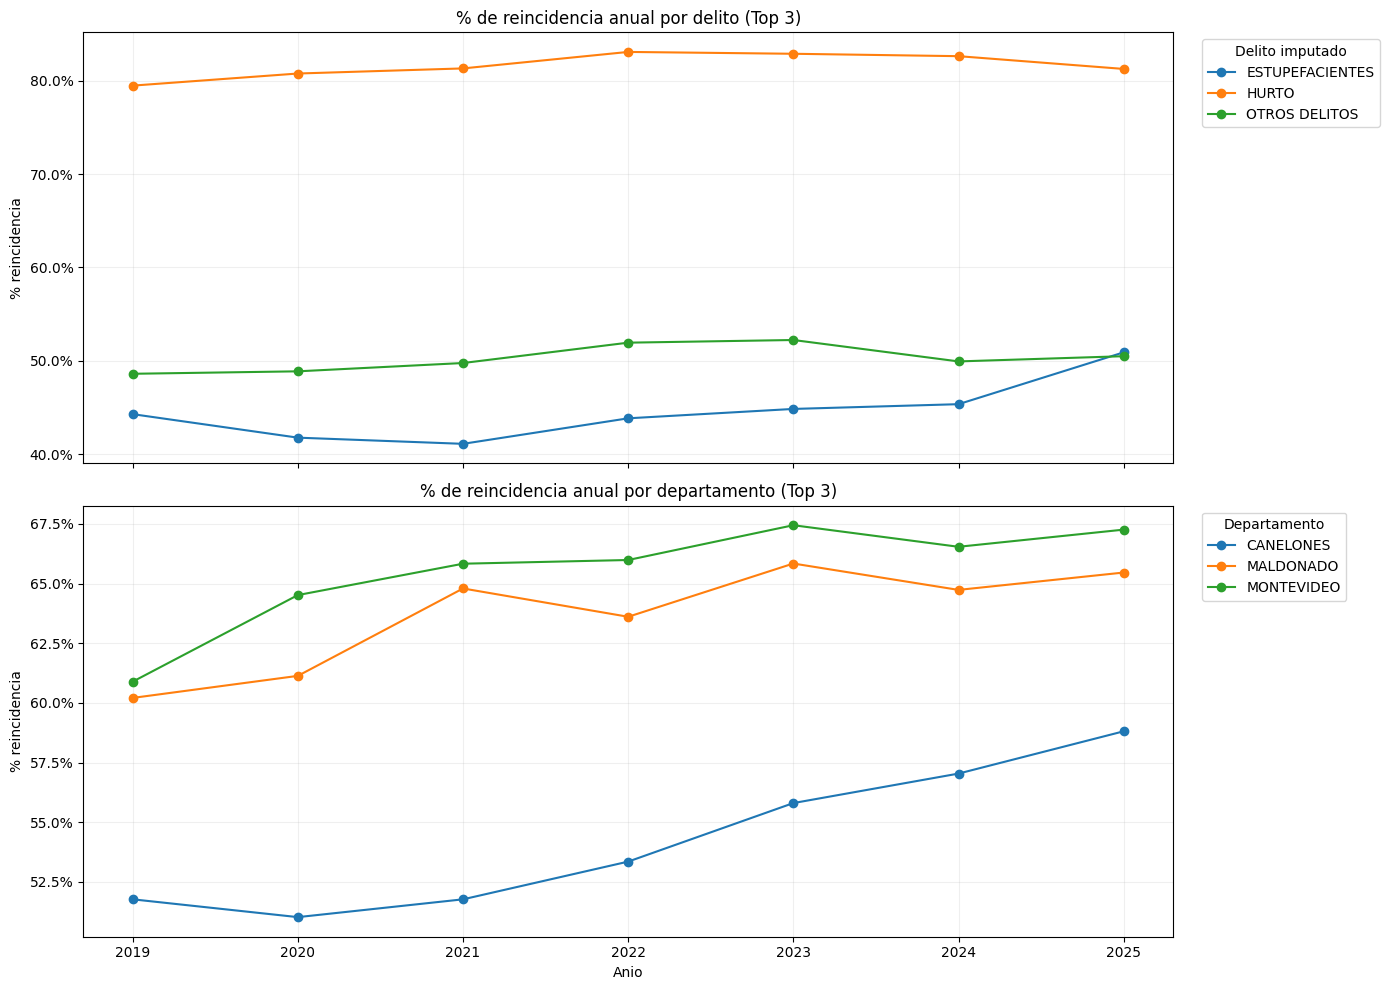

Top 3 delitos: ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES']
Top 3 departamentos: ['MONTEVIDEO', 'CANELONES', 'MALDONADO']
Cantidad de id_documento reincidentes globales: 23845

% reincidencia por delito (Top 3):


,delitos_agrupados,casos_totales,casos_reincidentes,pct_reincidencia
1,HURTO,39833,32548,81.711144
2,OTROS DELITOS,25280,12703,50.249209
0,ESTUPEFACIENTES,9345,4126,44.151953



% reincidencia por departamento (Top 3):


,depto_hechos,casos_totales,casos_reincidentes,pct_reincidencia
2,MONTEVIDEO,42265,27657,65.437123
1,MALDONADO,7299,4641,63.584053
0,CANELONES,17789,9668,54.348193


In [15]:
# % de reincidencia (top 5 delitos y top 5 departamentos) + evolucion anual
import matplotlib.ticker as mtick

# 1) IDs reincidentes en el dataset original (aparecen mas de 1 vez)
ids_reincidentes_global = (
    df.dropna(subset=['id_documento'])
    .groupby('id_documento')
    .size()
)
ids_reincidentes_global = ids_reincidentes_global[ids_reincidentes_global > 1].index

# 2) Base de analisis desde 2019 (para evitar sesgo por reincidencia previa a 2019)
fecha_inicio_rec = pd.Timestamp('2019-01-01')
base_analisis = df.dropna(subset=['id_documento', 'fecha_hecho', 'depto_hechos', 'delitos_agrupados']).copy()
base_analisis = base_analisis[base_analisis['fecha_hecho'] >= fecha_inicio_rec].copy()
base_analisis['es_reincidente_global'] = base_analisis['id_documento'].isin(ids_reincidentes_global)
base_analisis['anio'] = base_analisis['fecha_hecho'].dt.year

# 3) Top 3 delitos y top 3 departamentos por cantidad de casos
top3_delitos_rec = (
    base_analisis.groupby('delitos_agrupados', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['delitos_agrupados']
    .tolist()
)

top3_deptos_rec = (
    base_analisis.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

# 4) % de reincidencia por delito (top 3)
tabla_pct_delito = (
    base_analisis[base_analisis['delitos_agrupados'].isin(top3_delitos_rec)]
    .groupby('delitos_agrupados', as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
tabla_pct_delito['pct_reincidencia'] = (
    tabla_pct_delito['casos_reincidentes'] / tabla_pct_delito['casos_totales'] * 100
)
tabla_pct_delito = tabla_pct_delito.sort_values('pct_reincidencia', ascending=False)

# 5) % de reincidencia por departamento (top 3)
tabla_pct_depto = (
    base_analisis[base_analisis['depto_hechos'].isin(top3_deptos_rec)]
    .groupby('depto_hechos', as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
tabla_pct_depto['pct_reincidencia'] = (
    tabla_pct_depto['casos_reincidentes'] / tabla_pct_depto['casos_totales'] * 100
)
tabla_pct_depto = tabla_pct_depto.sort_values('pct_reincidencia', ascending=False)

# 6) Evolucion anual del % de reincidencia por delito (top 3)
evolucion_anual_delito = (
    base_analisis[base_analisis['delitos_agrupados'].isin(top3_delitos_rec)]
    .groupby(['anio', 'delitos_agrupados'], as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
evolucion_anual_delito['pct_reincidencia'] = (
    evolucion_anual_delito['casos_reincidentes'] / evolucion_anual_delito['casos_totales'] * 100
)

# 7) Evolucion anual del % de reincidencia por departamento (top 3)
evolucion_anual_depto = (
    base_analisis[base_analisis['depto_hechos'].isin(top3_deptos_rec)]
    .groupby(['anio', 'depto_hechos'], as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
evolucion_anual_depto['pct_reincidencia'] = (
    evolucion_anual_depto['casos_reincidentes'] / evolucion_anual_depto['casos_totales'] * 100
)

# 8) Graficos de evolucion anual
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for delito, grp in evolucion_anual_delito.groupby('delitos_agrupados'):
    grp = grp.sort_values('anio')
    axes[0].plot(grp['anio'], grp['pct_reincidencia'], marker='o', label=delito)
axes[0].set_title('% de reincidencia anual por delito (Top 3)')
axes[0].set_ylabel('% reincidencia')
axes[0].grid(alpha=0.2)
axes[0].legend(title='Delito imputado', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

for depto, grp in evolucion_anual_depto.groupby('depto_hechos'):
    grp = grp.sort_values('anio')
    axes[1].plot(grp['anio'], grp['pct_reincidencia'], marker='o', label=depto)
axes[1].set_title('% de reincidencia anual por departamento (Top 3)')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('% reincidencia')
axes[1].grid(alpha=0.2)
axes[1].legend(title='Departamento', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print('Top 3 delitos:', top3_delitos_rec)
print('Top 3 departamentos:', top3_deptos_rec)
print('Cantidad de id_documento reincidentes globales:', len(ids_reincidentes_global))

print('\n% reincidencia por delito (Top 3):')
display(tabla_pct_delito)

print('\n% reincidencia por departamento (Top 3):')
display(tabla_pct_depto)

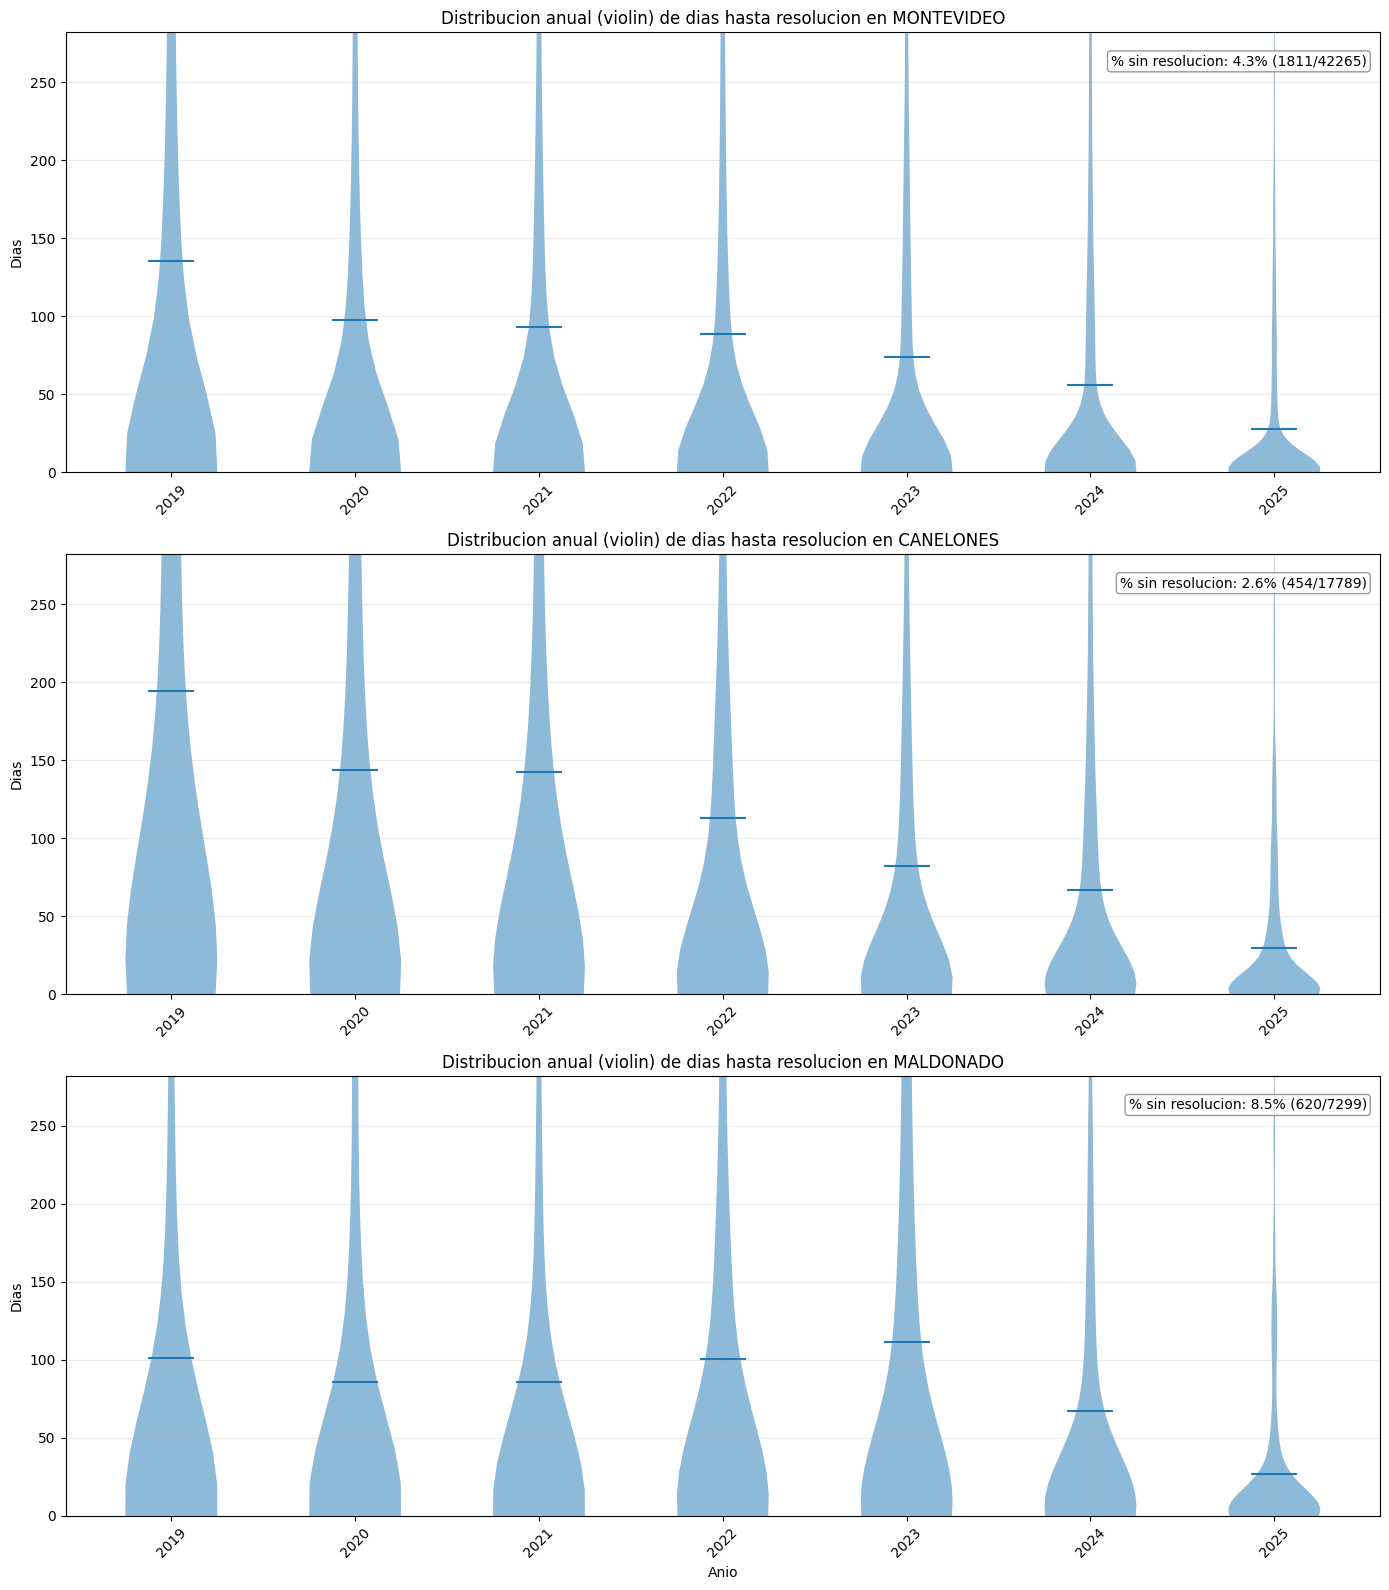

Limite superior eje Y (percentil 90): 282.0 dias
Top 3 departamentos (casos totales): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']

% de casos sin resolucion por departamento:


,depto_hechos,casos_evaluados,casos_sin_resolucion,pct_sin_resolucion
2,MONTEVIDEO,42265,1811,4.284869
1,MALDONADO,7299,620,8.494314
0,CANELONES,17789,454,2.552139



Resumen anual (incluye casos evaluados y resueltos):


,anio,depto_hechos,promedio_dias,desvio_std_dias,n_casos_resueltos,casos_evaluados
2,2019,MONTEVIDEO,135.416308,287.531118,6034,6285
5,2020,MONTEVIDEO,97.284091,227.902803,6160,6406
8,2021,MONTEVIDEO,92.838759,216.620014,5898,6026
11,2022,MONTEVIDEO,88.597416,194.120017,5805,5980
14,2023,MONTEVIDEO,73.787446,150.415514,6022,6220
17,2024,MONTEVIDEO,56.022268,111.071861,5793,6058
20,2025,MONTEVIDEO,27.653026,59.050602,4692,5290
13,2023,MALDONADO,111.576327,187.911164,904,1007
1,2019,MALDONADO,101.516537,241.330362,1028,1048
10,2022,MALDONADO,100.812081,200.674195,894,981


In [16]:
# Tiempo entre fecha_hecho y fecha_resolucion por departamento (Top 3), promedio y desviacion estandar anual
import numpy as np

# Detectar columna de fecha de resolucion (puede variar por codificacion)
col_res_candidates = [c for c in df.columns if c.lower().startswith('fecha_resoluci')]
if not col_res_candidates:
    raise ValueError('No se encontro la columna de fecha_resolucion en el dataset.')
col_fecha_resolucion = col_res_candidates[0]

base_tiempo = df.copy()
base_tiempo['fecha_hecho'] = pd.to_datetime(base_tiempo['fecha_hecho'], errors='coerce')
base_tiempo[col_fecha_resolucion] = pd.to_datetime(base_tiempo[col_fecha_resolucion], errors='coerce')

# Base desde 2019 para calcular % sin resolucion
base_tiempo = base_tiempo.dropna(subset=['fecha_hecho', 'depto_hechos']).copy()
base_tiempo = base_tiempo[base_tiempo['fecha_hecho'] >= pd.Timestamp('2019-01-01')].copy()

# Top 3 departamentos por cantidad de casos totales (incluye sin resolucion)
top3_deptos_tiempo = (
    base_tiempo.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

base_tiempo_top3 = base_tiempo[base_tiempo['depto_hechos'].isin(top3_deptos_tiempo)].copy()
base_tiempo_top3['anio'] = base_tiempo_top3['fecha_hecho'].dt.year

# % de casos sin resolucion por departamento
tabla_sin_res = (
    base_tiempo_top3.groupby('depto_hechos', as_index=False)
    .agg(
        casos_evaluados=(col_fecha_resolucion, 'size'),
        casos_sin_resolucion=(col_fecha_resolucion, lambda x: x.isna().sum())
    )
)
tabla_sin_res['pct_sin_resolucion'] = (
    tabla_sin_res['casos_sin_resolucion'] / tabla_sin_res['casos_evaluados'] * 100
)

# Filtrar registros resueltos y calcular dias transcurridos para el violin
base_resueltos = base_tiempo_top3.dropna(subset=[col_fecha_resolucion]).copy()
base_resueltos['dias_hasta_resolucion'] = (base_resueltos[col_fecha_resolucion] - base_resueltos['fecha_hecho']).dt.days
base_resueltos = base_resueltos[
    (base_resueltos['dias_hasta_resolucion'] >= 0) & (base_resueltos['dias_hasta_resolucion'] <= 3650)
]

# Casos evaluados por anio y departamento (incluye resueltos + no resueltos)
evaluados_anual = (
    base_tiempo_top3.groupby(['anio', 'depto_hechos'], as_index=False)
    .size()
    .rename(columns={'size': 'casos_evaluados'})
)

# Resumen anual de casos resueltos: promedio y desviacion estandar
resumen_anual_tiempo = (
    base_resueltos.groupby(['anio', 'depto_hechos'], as_index=False)
    .agg(
        promedio_dias=('dias_hasta_resolucion', 'mean'),
        desvio_std_dias=('dias_hasta_resolucion', 'std'),
        n_casos_resueltos=('dias_hasta_resolucion', 'size')
    )
)
resumen_anual_tiempo['desvio_std_dias'] = resumen_anual_tiempo['desvio_std_dias'].fillna(0)
resumen_anual_tiempo = resumen_anual_tiempo.merge(
    evaluados_anual,
    on=['anio', 'depto_hechos'],
    how='left'
 )

# Preparar anio para los graficos violin
base_resueltos['anio'] = base_resueltos['fecha_hecho'].dt.year

# Limite de eje Y usando percentil 90 para mejorar lectura
y_max = base_resueltos['dias_hasta_resolucion'].quantile(0.90)

# Grafico violin anual por departamento + % sin resolucion
fig, axes = plt.subplots(len(top3_deptos_tiempo), 1, figsize=(14, 16), sharex=False)
if len(top3_deptos_tiempo) == 1:
    axes = [axes]

for ax, depto in zip(axes, top3_deptos_tiempo):
    data_depto = base_resueltos[base_resueltos['depto_hechos'] == depto].copy()
    years = sorted(data_depto['anio'].dropna().unique())

    violin_data = [
        data_depto.loc[data_depto['anio'] == year, 'dias_hasta_resolucion'].values
        for year in years
    ]

    if len(violin_data) > 0 and sum(len(v) for v in violin_data) > 0:
        v = ax.violinplot(
            violin_data,
            positions=np.arange(1, len(years) + 1),
            showmeans=True,
            showextrema=False
        )
        for body in v['bodies']:
            body.set_alpha(0.5)

        ax.set_xticks(np.arange(1, len(years) + 1))
        ax.set_xticklabels(years, rotation=45)

    fila = tabla_sin_res[tabla_sin_res['depto_hechos'] == depto].iloc[0]
    pct_sin_res = fila['pct_sin_resolucion']
    casos_sin_res = int(fila['casos_sin_resolucion'])
    casos_eval = int(fila['casos_evaluados'])

    ax.set_title(f'Distribucion anual (violin) de dias hasta resolucion en {depto}')
    ax.set_ylabel('Dias')
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.25)
    ax.text(
        0.99, 0.95,
        f'% sin resolucion: {pct_sin_res:.1f}% ({casos_sin_res}/{casos_eval})',
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='gray')
    )

axes[-1].set_xlabel('Anio')
plt.tight_layout()
plt.show()

print(f'Limite superior eje Y (percentil 90): {y_max:.1f} dias')
print('Top 3 departamentos (casos totales):', top3_deptos_tiempo)
print('\n% de casos sin resolucion por departamento:')
display(tabla_sin_res.sort_values('depto_hechos', ascending=False))

print('\nResumen anual (incluye casos evaluados y resueltos):')
resumen_anual_tiempo.sort_values(['depto_hechos', 'promedio_dias'], ascending=[False, False]).head(20)

## Mapa de tasa de imputaciones cada 10.000 habitantes por departamento

Los gráficos anteriores (torta y evolución temporal) muestran el **número absoluto** de causas por departamento, dominado por Montevideo y Canelones simplemente porque ahí vive la mayor parte de la población. Para comparar departamentos de forma justa se calcula la tasa de imputaciones cada 10.000 habitantes, usando la población del Censo 2023 (INE), y se grafica sobre el mapa de Uruguay.

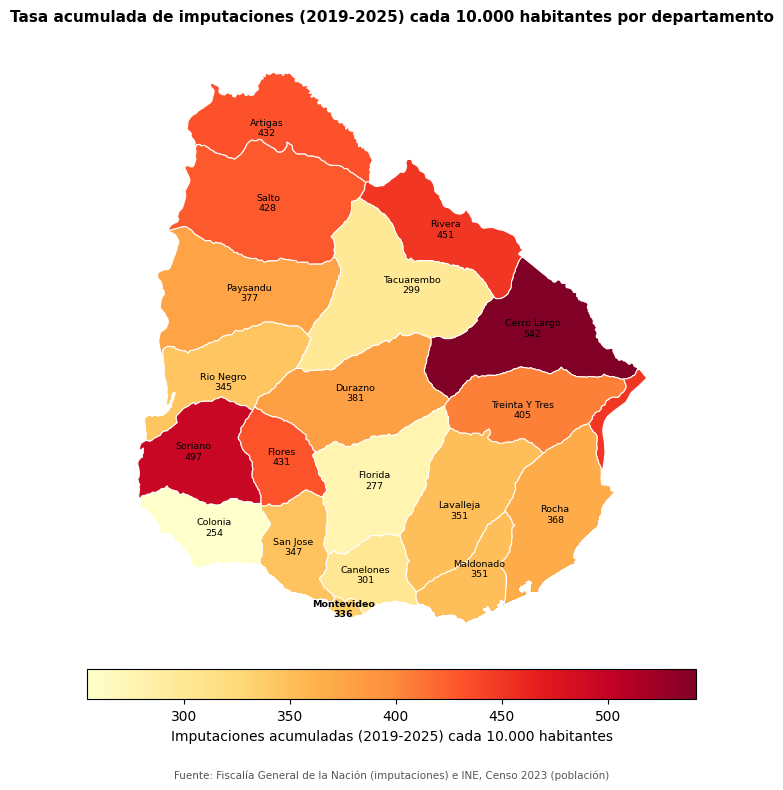

,depto_hechos,numero_delitos,poblacion,tasa_10k
4,CERRO LARGO,4933,91025,541.939028
7,SORIANO,4159,83685,496.982733
5,RIVERA,4924,109300,450.503202
10,ARTIGAS,3350,77487,432.330584
18,FLORES,1132,26271,430.893381
3,SALTO,5832,136197,428.203264
17,TREINTA Y TRES,1933,47706,405.190123
13,DURAZNO,2363,62011,381.061425
6,PAYSANDU,4591,121843,376.796369
11,ROCHA,2970,80707,367.997819


In [17]:
# Mapa coropletico: tasa de imputaciones cada 10.000 habitantes por departamento
# Requiere: geopandas, matplotlib. Descarga el geojson publico de departamentos si no esta en disco.
import geopandas as gpd
import matplotlib.pyplot as plt
import unicodedata, os, urllib.request

geojson_path = "uruguay.geojson"
geojson_url = "https://raw.githubusercontent.com/alotropico/uruguay.geo/master/uruguay.geojson"
if not os.path.exists(geojson_path):
    urllib.request.urlretrieve(geojson_url, geojson_path)

# Poblacion por departamento, Censo 2023 (INE, www.citypopulation.de/en/uruguay/admin)
poblacion = {
    "ARTIGAS": 77487, "CANELONES": 608956, "CERRO LARGO": 91025, "COLONIA": 135797,
    "DURAZNO": 62011, "FLORES": 26271, "FLORIDA": 70325, "LAVALLEJA": 59175,
    "MALDONADO": 212951, "MONTEVIDEO": 1302954, "PAYSANDU": 121843,
    "RIO NEGRO": 57334, "RIVERA": 109300, "ROCHA": 80707, "SALTO": 136197,
    "SAN JOSE": 119714, "SORIANO": 83685, "TACUAREMBO": 96013, "TREINTA Y TRES": 47706,
}

def norm(s):
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.upper().strip()

# Tasa total (acumulada 2019-2025) cada 10.000 habitantes, sin anualizar:
# evita depender de fechas min/max, que son sensibles a errores de carga puntuales.
tasa_df = delitos_por_departamento.copy()
tasa_df['depto_norm'] = tasa_df['depto_hechos'].apply(norm)
tasa_df['poblacion'] = tasa_df['depto_norm'].map(poblacion)
tasa_df['tasa_10k'] = tasa_df['numero_delitos'] / tasa_df['poblacion'] * 10000

gdf = gpd.read_file(geojson_path)
gdf['depto_norm'] = gdf['NAME_1'].apply(norm)
merged = gdf.merge(tasa_df, on='depto_norm', how='left')
merged = merged.to_crs(epsg=32721)  # UTM 21S

fig, ax = plt.subplots(1, 1, figsize=(9, 8))
merged.plot(
    column='tasa_10k', cmap='YlOrRd', linewidth=0.8, edgecolor='white', ax=ax,
    legend=True,
    legend_kwds={'label': 'Imputaciones acumuladas (2019-2025) cada 10.000 habitantes',
                 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.02},
)
for _, row in merged.iterrows():
    rp = row['geometry'].representative_point()
    ax.annotate(
        f"{row['depto_hechos'].title()}\n{row['tasa_10k']:.0f}",
        xy=(rp.x, rp.y), ha='center', va='center', fontsize=6.8,
        fontweight='bold' if row['depto_hechos'] == 'MONTEVIDEO' else 'normal',
    )
ax.set_axis_off()
ax.set_title(
    "Tasa acumulada de imputaciones (2019-2025) cada 10.000 habitantes por departamento",
    fontsize=11, fontweight='bold',
)
fig.text(0.5, 0.02, 'Fuente: Fiscalía General de la Nación (imputaciones) e INE, Censo 2023 (población)',
          ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
plt.show()

tasa_df.sort_values('tasa_10k', ascending=False)[['depto_hechos', 'numero_delitos', 'poblacion', 'tasa_10k']]

## Análisis de supervivencia: tiempo hasta resolución con censura (Kaplan-Meier)

El promedio simple de `dias_hasta_resolucion` calculado más arriba solo usa las causas ya resueltas y por lo tanto subestima el tiempo real cuando hay censura (causas que todavía no se resolvieron). Para corregir esto se define, por cada causa, un tiempo de supervivencia y un indicador de evento:

- Si la causa está resuelta (`fecha_resolución` no nula): `evento = 1` y la duración es `fecha_resolución - fecha_hecho`.
- Si no está resuelta: `evento = 0` (censurada) y la duración es `FECHA_CORTE - fecha_hecho`, donde `FECHA_CORTE` es la fecha de la última actualización publicada del conjunto de datos (marzo de 2026). Este supuesto debe ajustarse si se dispone de la fecha real de extracción.

Con esto se estiman curvas de Kaplan–Meier por departamento y por delito, y se compara la igualdad de las curvas con una prueba de log-rank.

In [18]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import numpy as np

FECHA_CORTE = pd.Timestamp('2026-03-09')  # ultima actualizacion publicada del dataset (ajustar si se conoce la fecha real de extraccion)

surv_base = base_tiempo_top3.copy()
surv_base['evento'] = surv_base[col_fecha_resolucion].notna().astype(int)
surv_base['duracion'] = np.where(
    surv_base['evento'] == 1,
    (surv_base[col_fecha_resolucion] - surv_base['fecha_hecho']).dt.days,
    (FECHA_CORTE - surv_base['fecha_hecho']).dt.days,
)
surv_base = surv_base[(surv_base['duracion'] >= 0) & (surv_base['duracion'] <= 3650)]

print(f"Causas para el analisis de supervivencia: {len(surv_base)}")
print(f"Proporcion censurada (sin resolucion): {(1 - surv_base['evento'].mean()):.1%}")

Causas para el analisis de supervivencia: 67239
Proporcion censurada (sin resolucion): 4.3%


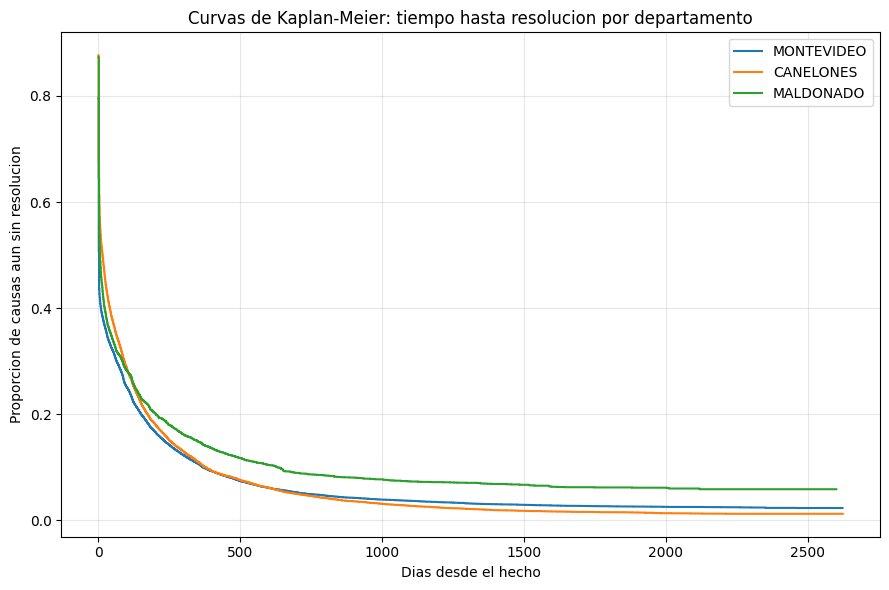

Log-rank entre departamentos: estadistico=302.72, p-valor=1.838e-66


In [19]:
# Kaplan-Meier por departamento (Top 3)
fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
for depto in top3_deptos_tiempo:
    sub = surv_base[surv_base['depto_hechos'] == depto]
    kmf.fit(sub['duracion'], event_observed=sub['evento'], label=depto)
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel('Dias desde el hecho')
ax.set_ylabel('Proporcion de causas aun sin resolucion')
ax.set_title('Curvas de Kaplan-Meier: tiempo hasta resolucion por departamento')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

resultado_logrank_depto = multivariate_logrank_test(
    surv_base['duracion'], surv_base['depto_hechos'], surv_base['evento']
)
print(f"Log-rank entre departamentos: estadistico={resultado_logrank_depto.test_statistic:.2f}, "
      f"p-valor={resultado_logrank_depto.p_value:.4g}")

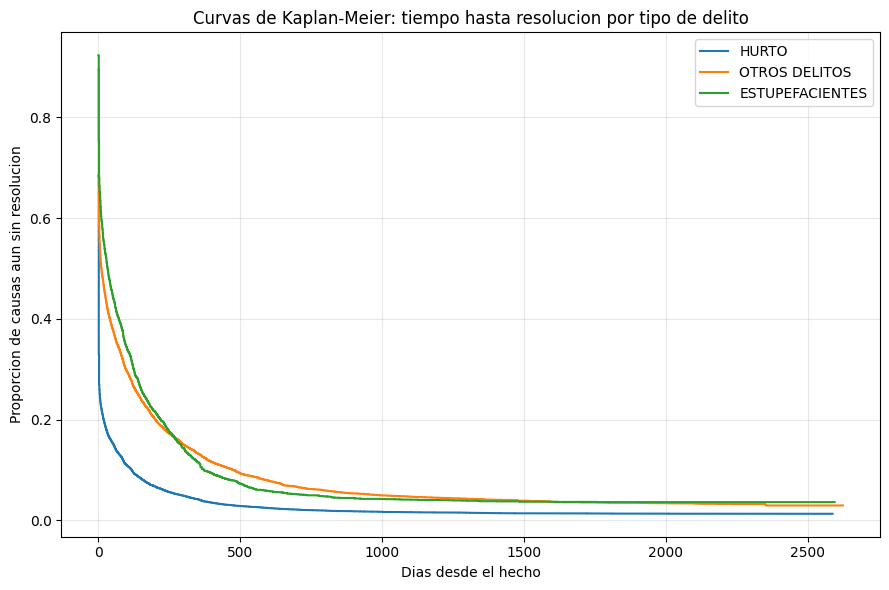

Log-rank entre delitos: estadistico=11039.28, p-valor=0


In [20]:
# Kaplan-Meier por tipo de delito (Top 3, calculados en la celda de evolucion temporal)
fig, ax = plt.subplots(figsize=(9, 6))
kmf2 = KaplanMeierFitter()
for delito in top3_delitos_2019:
    sub = surv_base[surv_base['delitos_agrupados'] == delito]
    if len(sub) == 0:
        continue
    kmf2.fit(sub['duracion'], event_observed=sub['evento'], label=delito)
    kmf2.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel('Dias desde el hecho')
ax.set_ylabel('Proporcion de causas aun sin resolucion')
ax.set_title('Curvas de Kaplan-Meier: tiempo hasta resolucion por tipo de delito')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

resultado_logrank_delito = multivariate_logrank_test(
    surv_base['duracion'], surv_base['delitos_agrupados'], surv_base['evento']
)
print(f"Log-rank entre delitos: estadistico={resultado_logrank_delito.test_statistic:.2f}, "
      f"p-valor={resultado_logrank_delito.p_value:.4g}")

## Modelo de probabilidad de causa sin resolver (regresión logística)

Como complemento a las curvas de supervivencia, se estima un modelo de regresión logística para la probabilidad de que una causa permanezca sin resolver (`sin_resolucion`), en función del departamento, el tipo de delito, la edad y el sexo de la persona imputada, controlando por año del hecho. Se restringe el modelo a los 5 departamentos y los 5 delitos agrupados con más casos, para evitar categorías con muy pocas observaciones. `sexo_persona` y `edad_num` se incluyen únicamente como variables de control descriptivas, no como base de decisiones individuales (ver consideraciones éticas).

In [21]:
import statsmodels.formula.api as smf

base_modelo = df.copy()
base_modelo['fecha_hecho'] = pd.to_datetime(base_modelo['fecha_hecho'], errors='coerce')
base_modelo[col_fecha_resolucion] = pd.to_datetime(base_modelo[col_fecha_resolucion], errors='coerce')
base_modelo['edad_num'] = pd.to_numeric(base_modelo['edad'].astype(str).str.replace(',', '.'), errors='coerce')
base_modelo['anio_hecho'] = base_modelo['fecha_hecho'].dt.year

base_modelo = base_modelo.dropna(
    subset=['fecha_hecho', 'depto_hechos', 'delitos_agrupados', 'sexo_persona', 'edad_num', 'anio_hecho']
)
base_modelo = base_modelo[base_modelo['fecha_hecho'] >= pd.Timestamp('2019-01-01')].copy()
base_modelo['sin_resolucion'] = base_modelo[col_fecha_resolucion].isna().astype(int)

top5_delitos = base_modelo['delitos_agrupados'].value_counts().head(5).index
top5_deptos = base_modelo['depto_hechos'].value_counts().head(5).index
base_modelo_reducida = base_modelo[
    base_modelo['delitos_agrupados'].isin(top5_delitos) & base_modelo['depto_hechos'].isin(top5_deptos)
].copy()

print(f"Observaciones para el modelo: {len(base_modelo_reducida)}")

modelo = smf.logit(
    "sin_resolucion ~ C(depto_hechos, Treatment(reference='MONTEVIDEO')) "
    "+ C(delitos_agrupados, Treatment(reference='HURTO')) "
    "+ edad_num + C(sexo_persona) + C(anio_hecho)",
    data=base_modelo_reducida,
).fit()

print(modelo.summary())

Observaciones para el modelo: 60373
Optimization terminated successfully.
         Current function value: 0.131376
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         sin_resolucion   No. Observations:                60373
Model:                          Logit   Df Residuals:                    60356
Method:                           MLE   Df Model:                           16
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                 0.08298
Time:                        21:19:17   Log-Likelihood:                -7931.6
converged:                       True   LL-Null:                       -8649.3
Covariance Type:            nonrobust   LLR p-value:                3.848e-296
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [22]:
# Odds ratios (mas interpretables que los coeficientes en escala logit)
odds_ratios = np.exp(modelo.params).rename('OR')
ic = np.exp(modelo.conf_int())
ic.columns = ['IC_95_inf', 'IC_95_sup']
tabla_or = pd.concat([odds_ratios, ic], axis=1)
tabla_or.sort_values('OR', ascending=False)

,OR,IC_95_inf,IC_95_sup
C(anio_hecho)[T.2025],3.575786,3.050681,4.191274
"C(delitos_agrupados, Treatment(reference='HURTO'))[T.OTROS DELITOS]",2.688951,2.401513,3.010793
"C(depto_hechos, Treatment(reference='MONTEVIDEO'))[T.MALDONADO]",2.478549,2.206882,2.783658
"C(delitos_agrupados, Treatment(reference='HURTO'))[T.VIOLENCIA DOMÉSTICA]",2.464788,2.058562,2.951177
"C(delitos_agrupados, Treatment(reference='HURTO'))[T.RAPIÑA]",2.399961,2.067517,2.785861
"C(delitos_agrupados, Treatment(reference='HURTO'))[T.ESTUPEFACIENTES]",2.054096,1.726477,2.443884
C(anio_hecho)[T.2024],1.129053,0.937215,1.360157
C(anio_hecho)[T.2020],1.081645,0.899734,1.300335
C(anio_hecho)[T.2023],1.032579,0.853937,1.248592
edad_num,1.009163,1.004600,1.013747


## Entrenamiento y comparación de modelos de clasificación

Se entrenan varios clasificadores para predecir `sin_resolucion` (si una causa queda sin resolver) a partir de departamento, delito agrupado, sexo, año del hecho y edad, usando la misma base `base_modelo_reducida` de la regresión logística. Se comparan regresión logística, Naive Bayes, Random Forest, SVM y KNN con métricas apropiadas para un problema desbalanceado (precision, recall, F1 y AUC, no solo accuracy).

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

features_cat = ['depto_hechos', 'delitos_agrupados', 'sexo_persona', 'anio_hecho']
features_num = ['edad_num']

X = base_modelo_reducida[features_cat + features_num]
y = base_modelo_reducida['sin_resolucion']

print("Balance de clases:")
print(y.value_counts(normalize=True).rename('proporcion'))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

preprocesador = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
    ('num', StandardScaler(), features_num),
])

Balance de clases:
sin_resolucion
0    0.967519
1    0.032481
Name: proporcion, dtype: float64


In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

resultados = []

def evaluar_modelo(nombre, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
    }
    resultados.append(metrics)

    print(f"--- {nombre} ---")
    for k, v in metrics.items():
        if k != 'modelo':
            print(f"{k}: {v:.3f}")
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, y_pred))
    return y_proba

### Regresión logística (sklearn)

In [25]:
from sklearn.linear_model import LogisticRegression

pipe_logit = Pipeline([
    ('prep', preprocesador),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])
pipe_logit.fit(X_train, y_train)
proba_logit = evaluar_modelo('Regresion logistica', pipe_logit, X_test, y_test)

--- Regresion logistica ---
accuracy: 0.633
precision: 0.060
recall: 0.708
f1: 0.111
auc: 0.724
Matriz de confusion:
[[9204 5400]
 [ 143  347]]


### Naive Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB

X_train_dense = preprocesador.fit_transform(X_train).toarray()
X_test_dense = preprocesador.transform(X_test).toarray()

nb_model = GaussianNB()
nb_model.fit(X_train_dense, y_train)

y_pred = nb_model.predict(X_test_dense)
y_proba = nb_model.predict_proba(X_test_dense)[:, 1]
resultados.append({
    'modelo': 'Naive Bayes',
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_proba),
})
proba_nb = y_proba
print(confusion_matrix(y_test, y_pred))

[[13404  1200]
 [  339   151]]


### Random Forest (+ importancia de variables)

--- Random Forest ---
accuracy: 0.675
precision: 0.067
recall: 0.700
f1: 0.123
auc: 0.747
Matriz de confusion:
[[9847 4757]
 [ 147  343]]


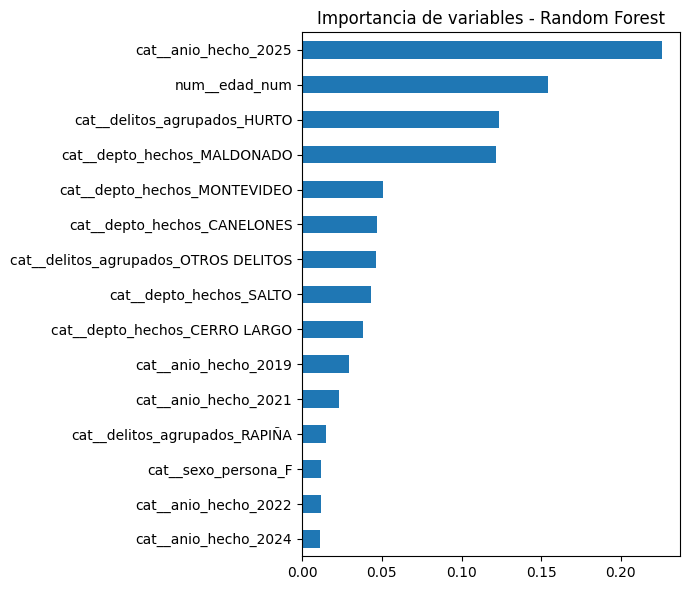

In [27]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)),
])
pipe_rf.fit(X_train, y_train)
proba_rf = evaluar_modelo('Random Forest', pipe_rf, X_test, y_test)

nombres_cols = pipe_rf.named_steps['prep'].get_feature_names_out()
importancias = pd.Series(pipe_rf.named_steps['clf'].feature_importances_, index=nombres_cols)
importancias.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(7, 6))
plt.gca().invert_yaxis()
plt.title('Importancia de variables - Random Forest')
plt.tight_layout()
plt.show()

### SVM

In [28]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('prep', preprocesador),
    ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)),
])
#pipe_svm.fit(X_train, y_train)
muestra = X_train.sample(10000, random_state=42)
pipe_svm.fit(muestra, y_train.loc[muestra.index])
proba_svm = evaluar_modelo('SVM', pipe_svm, X_test, y_test)


C:\Users\germa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- SVM ---
accuracy: 0.725
precision: 0.062
recall: 0.531
f1: 0.111
auc: 0.676
Matriz de confusion:
[[10688  3916]
 [  230   260]]


### KNN

In [32]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ('prep', preprocesador),
    ('clf', KNeighborsClassifier(n_neighbors=15)),
])
pipe_knn.fit(X_train, y_train)
proba_knn = evaluar_modelo('KNN', pipe_knn, X_test, y_test)

--- KNN ---
accuracy: 0.968
precision: 0.000
recall: 0.000
f1: 0.000
auc: 0.655
Matriz de confusion:
[[14604     0]
 [  490     0]]


### Tabla comparativa y curvas ROC

,accuracy,precision,recall,f1,auc
modelo,,,,,
Random Forest,0.675,0.067,0.700,0.123,0.747
Regresion logistica,0.633,0.060,0.708,0.111,0.724
Naive Bayes,0.898,0.112,0.308,0.164,0.723
SVM,0.725,0.062,0.531,0.111,0.676
KNN,0.968,0.000,0.000,0.000,0.655


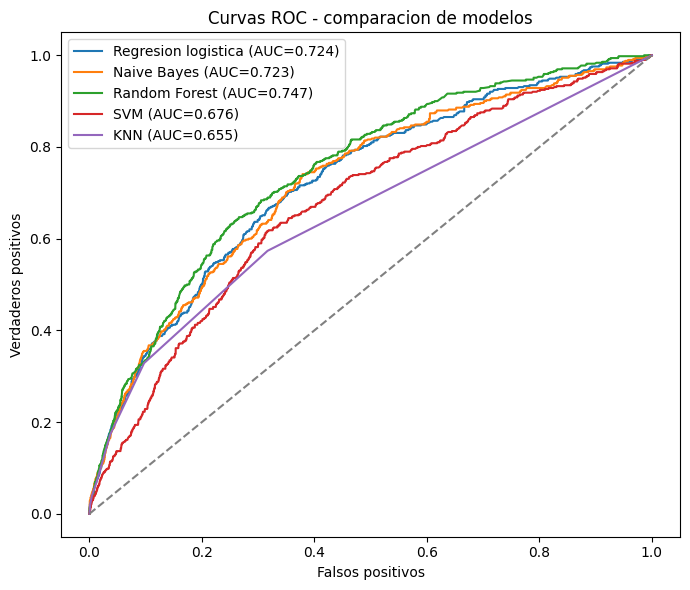

In [35]:
tabla_comparativa = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset='modelo', keep='last')
    .set_index('modelo')
    .sort_values('auc', ascending=False)
)
display(tabla_comparativa.style.format('{:.3f}').background_gradient(cmap='YlGnBu', axis=0))
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
for nombre, proba in [('Regresion logistica', proba_logit), ('Naive Bayes', proba_nb),
                       ('Random Forest', proba_rf), ('SVM', proba_svm), ('KNN', proba_knn)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('Falsos positivos')
ax.set_ylabel('Verdaderos positivos')
ax.set_title('Curvas ROC - comparacion de modelos')
ax.legend()
plt.tight_layout()
plt.show()

### Presentación mejorada de la regresión logística (forest plot de odds ratios)

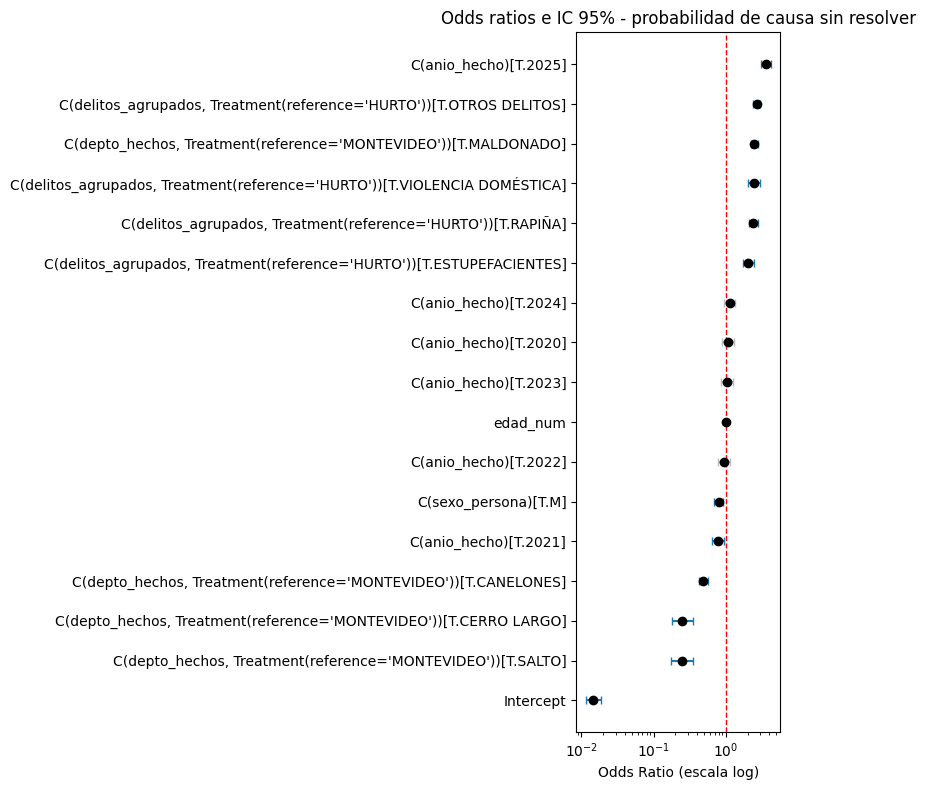

In [38]:
tabla_or_presentable = tabla_or.copy()
tabla_or_presentable['significativo'] = (tabla_or_presentable['IC_95_inf'] > 1) | (tabla_or_presentable['IC_95_sup'] < 1)
tabla_or_presentable = tabla_or_presentable.sort_values('OR', ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))

for i, (nombre, fila) in enumerate(tabla_or_presentable.iterrows()):
    color = '#1F77B4' if fila['significativo'] else '#BBBBBB'
    ax.errorbar(
        fila['OR'], i,
        xerr=[[fila['OR'] - fila['IC_95_inf']], [fila['IC_95_sup'] - fila['OR']]],
        fmt='o', color='black', ecolor=color, capsize=3,
    )

ax.axvline(1, linestyle='--', color='red', linewidth=1)
ax.set_yticks(range(len(tabla_or_presentable)))
ax.set_yticklabels(tabla_or_presentable.index)
ax.set_xlabel('Odds Ratio (escala log)')
ax.set_xscale('log')
ax.set_title('Odds ratios e IC 95% - probabilidad de causa sin resolver')
plt.tight_layout()
plt.show()